# Análise de Demandas em Python (Pandas)
### Módulo 6 · Portfólio PMO de Dados — TechFinance S.A.

Reprodução das análises do **Painel de Produtividade** (Power BI) usando Python e Pandas,
a partir do dataset bruto normalizado em 6 tabelas (Star Schema).

**Objetivo:** demonstrar fluência de leitura e manipulação de dados em Python — carregar,
tratar, cruzar e agregar dados — validando os resultados contra o dashboard já publicado.

**Dados:** 420 demandas sintéticas · 8 squads · Jan/2024 a Jun/2025.

---

## 1. Carga e reconstrução do Star Schema

A fato (`demandas`) chega com chaves numéricas (`SquadID`, `StatusID`...). Cada `merge`
substitui um ID pelo atributo legível da dimensão correspondente — o equivalente a um
`LEFT JOIN` em SQL. O resultado é uma tabela única e legível com 420 linhas.

In [31]:
import pandas as pd

df = pd.read_csv("demandas_tratado.csv", encoding="utf-8")

print(df.shape)   # deve mostrar (420, 13)
df.head()

(420, 13)


,DemandaID,Titulo,Squad,Area,StatusNome,PrioridadeNome,Nivel,SLA_Dias,CategoriaNome,Responsavel,DataAbertura,DataPrazo,DataFechamento
0,1,Catálogo de dados do domínio #0001,Squad Dados,Data & Analytics,Concluído,Crítica,1,5,Desenvolvimento,Marina Oliveira,2024-05-22,2024-05-26,2024-05-28
1,2,Validação de documentos KYC #0002,Squad Onboarding,Experiência do Cliente,Concluído,Crítica,1,5,Desenvolvimento,Isabela Nunes,2024-01-28,2024-02-03,2024-02-01
2,3,Auditoria de logs de segurança #0003,Squad Segurança,Tecnologia e Infraestrutura,Concluído,Alta,2,10,Infraestrutura,João Cardoso,2025-03-08,2025-03-21,2025-03-21
3,4,Integração de API de Pagamentos #0004,Squad Pagamentos,Produtos Financeiros,Concluído,Média,3,20,Manutenção,Bruno Costa,2024-09-27,2024-10-15,2024-10-10
4,5,Dashboard de KPIs executivos #0005,Squad Dados,Data & Analytics,Aberto,Baixa,4,30,Melhoria,Nelson Gomes,2024-07-15,2024-08-13,NaN


## 2. Agregações — Demandas por Squad e por Status

`groupby` + `size()` reproduz o `COUNT(*) ... GROUP BY` do SQL. `crosstab` recria a
tabela dinâmica "Squad × Status". Os totais batem com o Painel do Power BI — mesma base,
mesma história.

In [32]:
# conta quantas demandas cada squad tem
por_squad = df.groupby("Squad").size().sort_values(ascending=False)
print(por_squad)

Squad
Squad Dados             83
Squad Pagamentos        74
Squad Integrações       64
Squad Crédito           52
Squad Onboarding        52
Squad Experiência       47
Squad Infraestrutura    24
Squad Segurança         24
dtype: int64


In [33]:
# tabela cruzada: squads nas linhas, status nas colunas
squad_status = pd.crosstab(df["Squad"], df["StatusNome"])
print(squad_status)

StatusNome            Aberto  Bloqueado  Cancelado  Concluído  Em Andamento
Squad                                                                      
Squad Crédito              1          3          2         38             8
Squad Dados                7          3          7         54            12
Squad Experiência          5          3          2         26            11
Squad Infraestrutura       1          2          3         12             6
Squad Integrações          5          5          6         40             8
Squad Onboarding           5          2          2         39             4
Squad Pagamentos           5          8          7         48             6
Squad Segurança            1          3          2         13             5


## 3. Análise de SLA

O SLA usa como base as **demandas fechadas** (301), não o total (420) — demandas em aberto
não têm cumprimento de prazo a avaliar. Uma demanda cumpre o SLA quando
`DataFechamento <= DataPrazo`.

**Resultado: 228 de 301 = 75,75% de SLA cumprido** — idêntico ao card do dashboard.

In [34]:
# 1) converter as colunas de data (hoje são texto) para tipo data de verdade
df["DataPrazo"] = pd.to_datetime(df["DataPrazo"])
df["DataFechamento"] = pd.to_datetime(df["DataFechamento"])

# 2) criar a coluna: cumpriu o SLA? (só faz sentido pra demandas fechadas)
df["Cumpriu_SLA"] = df["DataFechamento"] <= df["DataPrazo"]

# 3) ver o resultado só das demandas que já foram fechadas
fechadas = df[df["DataFechamento"].notna()]
print(f"Demandas fechadas: {len(fechadas)}")
print(f"Cumpriram o SLA: {fechadas['Cumpriu_SLA'].sum()}")
print(f"% SLA: {fechadas['Cumpriu_SLA'].mean():.1%}")

Demandas fechadas: 301
Cumpriram o SLA: 228
% SLA: 75.7%


## 4. Visualizações

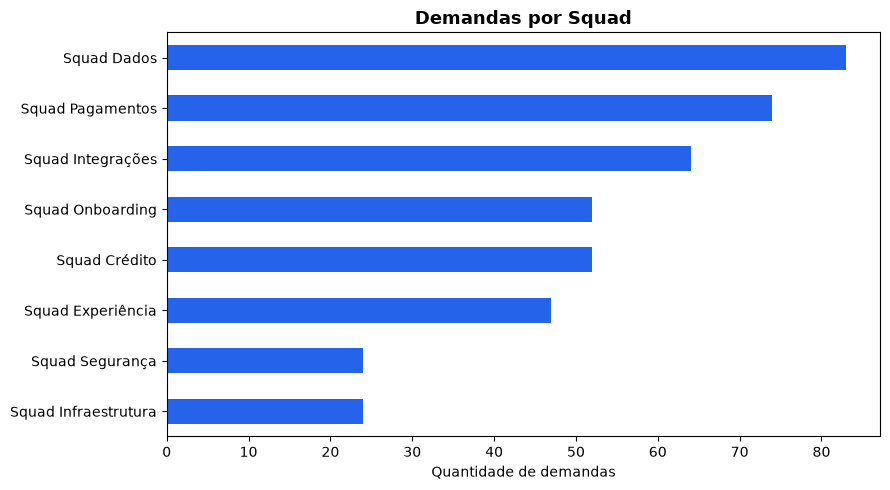

In [35]:
import matplotlib.pyplot as plt

# reusa a análise que você já fez
por_squad = df.groupby("Squad").size().sort_values(ascending=True)

plt.figure(figsize=(9, 5))
por_squad.plot(kind="barh", color="#2563EB")
plt.title("Demandas por Squad", fontsize=13, fontweight="bold")
plt.xlabel("Quantidade de demandas")
plt.ylabel("")
plt.tight_layout()
plt.show()

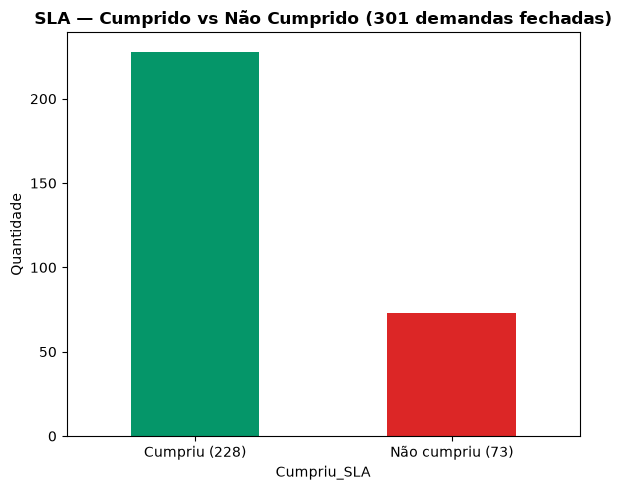

In [36]:
# distribuição: cumpriu vs não cumpriu (só fechadas)
sla_contagem = fechadas["Cumpriu_SLA"].value_counts()

plt.figure(figsize=(6, 5))
sla_contagem.plot(
    kind="bar",
    color=["#059669", "#DC2626"]   # verde = cumpriu, vermelho = não
)
plt.title("SLA — Cumprido vs Não Cumprido (301 demandas fechadas)", fontsize=12, fontweight="bold")
plt.xticks([0, 1], ["Cumpriu (228)", "Não cumpriu (73)"], rotation=0)
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

## Conclusão

Esta análise reproduz em Python os indicadores do Painel de Produtividade, validando os
números contra o dashboard: **420 demandas**, distribuição por squad idêntica, e
**SLA de 75,75%** sobre as 301 demandas fechadas.

O mesmo dataset foi analisado em **SQL, Power BI, Excel e Pandas** — demonstrando que a
consistência dos indicadores independe da ferramenta, competência central de um PMO de Dados.

---
*Dados sintéticos — TechFinance S.A. (contexto fictício). Portfólio PMO de Dados.*